In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [22]:
# Load data
df = pd.read_csv(
    "D:/SALEM_AI/Machine Learning Models/1-Citizen Trust Score Model/Dataset/citizen_trust_dataset_v2.csv"
    )

print("✅ Dataset Loaded")

print(df.head())

✅ Dataset Loaded
   citizen_id  total_reports  valid_reports  duplicate_reports  \
0           1             11              8                  2   
1           2             11             10                  2   
2           3              9              7                  1   
3           4             14             11                  0   
4           5             16             15                  2   

   fake_image_count  avg_severity_reported  reports_last_30_days  trust_label  \
0                 0                   2.40                     0            1   
1                 0                   1.71                     3            1   
2                 0                   2.99                     3            1   
3                 0                   2.29                     0            1   
4                 0                   2.43                     2            1   

   valid_ratio  duplicate_rate  fake_image_ratio  
0     0.727273        0.181818               0.0

In [23]:
# Features & Target
features = [
    "valid_ratio",
    "duplicate_rate",
    "fake_image_ratio",
    "reports_last_30_days",
    "avg_severity_reported"
]

X = df[features]

y = df["trust_label"]


In [24]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✅ Data Split Complete")

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


✅ Data Split Complete
X_train Shape: (16000, 5)
X_test Shape : (4000, 5)


In [32]:
# Train Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\n✅ Model Trained Successfully")


✅ Model Trained Successfully


In [33]:
# Predictions
y_pred = model.predict(X_test)

In [34]:
# Evaluation
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========================")
print("Accuracy:", accuracy)
print("========================\n")

print(classification_report(
    y_test,
    y_pred
))

print("\n========================\n")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


Accuracy: 0.85975

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1553
           1       0.84      0.95      0.89      2447

    accuracy                           0.86      4000
   macro avg       0.87      0.83      0.85      4000
weighted avg       0.86      0.86      0.86      4000



[[1122  431]
 [ 130 2317]]


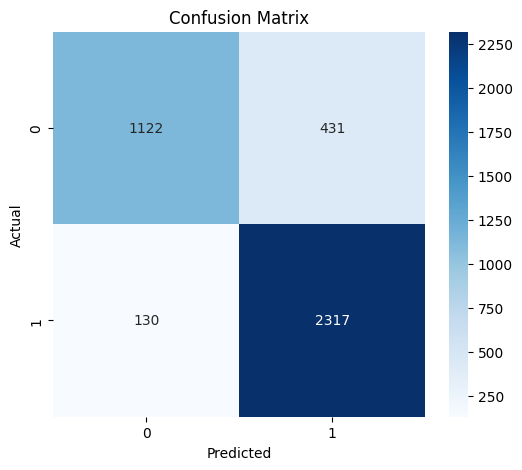

In [35]:
# Confusion Matrix Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [36]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n========================")
print("Feature Importance")
print("========================\n")

print(importance)


Feature Importance

                 Feature  Coefficient
0            valid_ratio     3.481252
3   reports_last_30_days    -0.132115
4  avg_severity_reported    -0.186264
1         duplicate_rate    -0.829734
2       fake_image_ratio    -1.824948


In [37]:
# Generate Trust Score
df["trust_score"] = model.predict_proba(X)[:, 1]
# Trust Level
def get_trust_level(score):

    if score >= 0.8:
        return "High"

    elif score >= 0.5:
        return "Medium"

    else:
        return "Low"

df["trust_level"] = df["trust_score"].apply(
    get_trust_level
)
# Save Dataset with Scores
df.to_csv(
    "D:/SALEM_AI/Machine Learning Models/1-Citizen Trust Score Model/Dataset/citizen_trust_with_score.csv", index=False
    )
print("✅ Dataset with Trust Score Saved")

✅ Dataset with Trust Score Saved


In [39]:
import joblib

joblib.dump(
    model,
    "D:/SALEM_AI/Machine Learning Models/1-Citizen Trust Score Model/model_pk/trust_model.pkl"
)

print("✅ Trust Model Saved")

✅ Trust Model Saved
